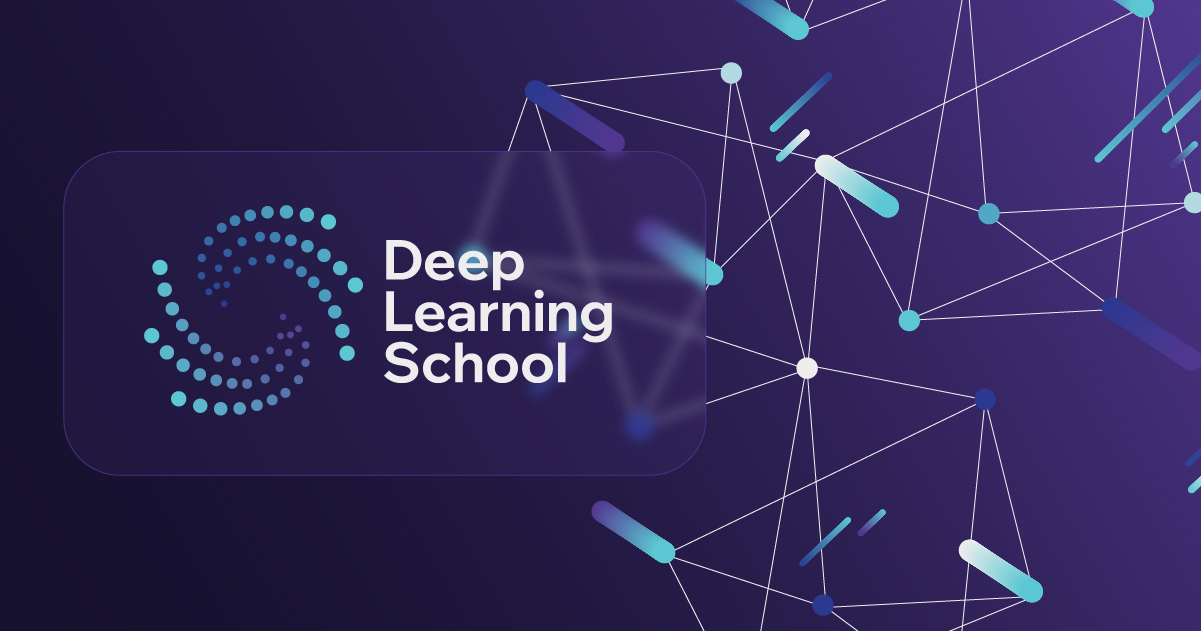


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [2]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [3]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Using Colab cache for faster access to the 'lfw-attributes' dataset.
Path to dataset files: /kaggle/input/lfw-attributes


In [4]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [5]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    # Загрузка атрибутов
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

    # Нормализация названий столбцов
    df_attrs.columns = df_attrs.columns.str.strip()

    # Сбор данных о фотографиях
    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    # Нормализация названий столбцов
    photo_ids.columns = photo_ids.columns.str.strip()

    # Приведение типов данных
    photo_ids['imagenum'] = photo_ids['imagenum'].astype(int)

    # Отладка: проверка столбцов
    print("Столбцы df_attrs:", df_attrs.columns.tolist())
    print("Столбцы photo_ids:", photo_ids.columns.tolist())

    # Слияние датафреймов
    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    # Обработка изображений
    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img: img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    return images, attrs

In [6]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()

Столбцы df_attrs: ['person', 'imagenum', 'Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth', 'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair', 'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling', 'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash', 'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair', 'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead', 'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows', 'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose', 'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open', 'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee', 'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face', 'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man', 'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes', 'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pale Skin', "5 o' Clock Shadow", 'Strong Nose-Mouth Lines',


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [7]:
from sklearn.model_selection import train_test_split

# Разбиваем датасет на обучающую и валидационную выборки (80%/20%)
X_train, X_val, y_train, y_val = train_test_split(
    images,
    attrs,
    test_size=0.2,
    random_state=42,
    stratify=None  # Можно использовать стратификацию по какому‑либо атрибуту, если нужно
)

print(f"Размер обучающей выборки: {X_train.shape[0]} изображений")
print(f"Размер валидационной выборки: {X_val.shape[0]} изображений")
print(f"Размер изображений: {X_train.shape[1]}x{X_train.shape[2]} пикселей")
print(f"Количество атрибутов: {y_train.shape[1]}")

Размер обучающей выборки: 10514 изображений
Размер валидационной выборки: 2629 изображений
Размер изображений: 45x45 пикселей
Количество атрибутов: 73


Примеры изображений из обучающей выборки:


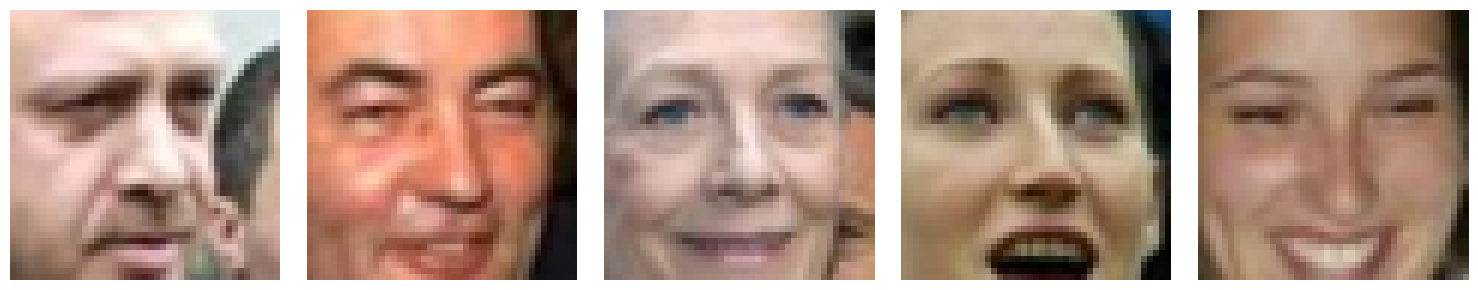

In [8]:
# Визуализация нескольких изображений
def show_sample_images(images, titles=None, n_samples=5):
    plt.figure(figsize=(15, 3))
    for i in range(n_samples):
        plt.subplot(1, n_samples, i + 1)
        img_to_show = images[i] / 255.0 if images[i].dtype == 'uint8' else images[i]
        plt.imshow(img_to_show)
        plt.axis('off')
        if titles is not None:
            plt.title(titles[i], fontsize=10)
    plt.tight_layout()
    plt.show()

print("Примеры изображений из обучающей выборки:")
show_sample_images(X_train)

In [9]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def clean_and_convert_attributes(attrs_df):
    """
    Очищает и преобразует датафрейм атрибутов в числовой формат
    """
    # Создаём копию, чтобы не изменять оригинальный датафрейм
    cleaned_df = attrs_df.copy()

    # Удаляем колонки с нечисловыми данными (если есть)
    # Оставляем только колонки с числовыми типами (int, float)
    numeric_columns = cleaned_df.select_dtypes(include=[np.number]).columns
    cleaned_df = cleaned_df[numeric_columns]

    # Заменяем NaN на 0 (или другое значение)
    cleaned_df = cleaned_df.fillna(0)

    # Приводим все значения к float32
    cleaned_df = cleaned_df.astype('float32')

    return cleaned_df

# Очищаем атрибуты
y_train_clean = clean_and_convert_attributes(y_train)
y_val_clean = clean_and_convert_attributes(y_val)

In [10]:
def convert_attributes_to_tensor(attrs):
    """
    Преобразует очищенный DataFrame атрибутов в тензор PyTorch
    """
    # Убеждаемся, что данные числовые и имеют правильный тип
    if not np.issubdtype(attrs.values.dtype, np.number):
        raise ValueError("Данные содержат нечисловые значения после очистки")

    return torch.tensor(attrs.values, dtype=torch.float32)

# Преобразуем атрибуты в тензоры
y_train_tensor = convert_attributes_to_tensor(y_train_clean)
y_val_tensor = convert_attributes_to_tensor(y_val_clean)

In [11]:
def preprocess_images_to_tensors(images):
    """
    Преобразует массив изображений в тензор PyTorch с нормализацией
    """
    # Нормализуем пиксели в диапазон [0, 1] и преобразуем в float32
    normalized_images = images.astype('float32') / 255.0

    # Меняем порядок размерностей с NHWC на NCHW (PyTorch формат)
    transposed_images = np.transpose(normalized_images, (0, 3, 1, 2))

    # Преобразуем в тензор PyTorch
    tensor_images = torch.tensor(transposed_images, dtype=torch.float32)
    return tensor_images

# Преобразуем изображения в тензоры
X_train_tensor = preprocess_images_to_tensors(X_train)
X_val_tensor = preprocess_images_to_tensors(X_val)

In [12]:
# Создаём Dataset объекты
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Создаём DataLoader с указанием размера батча
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Форма тензора обучающих изображений: {X_train_tensor.shape}")
print(f"Форма тензора валидационных изображений: {X_val_tensor.shape}")
print(f"Форма тензора обучающих атрибутов: {y_train_tensor.shape}")
print(f"Форма тензора валидационных атрибутов: {y_val_tensor.shape}")
print(f"Количество батчей в обучающей выборке: {len(train_loader)}")
print(f"Количество батчей в валидационной выборке: {len(val_loader)}")

Форма тензора обучающих изображений: torch.Size([10514, 3, 45, 45])
Форма тензора валидационных изображений: torch.Size([2629, 3, 45, 45])
Форма тензора обучающих атрибутов: torch.Size([10514, 0])
Форма тензора валидационных атрибутов: torch.Size([2629, 0])
Количество батчей в обучающей выборке: 329
Количество батчей в валидационной выборке: 83


## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



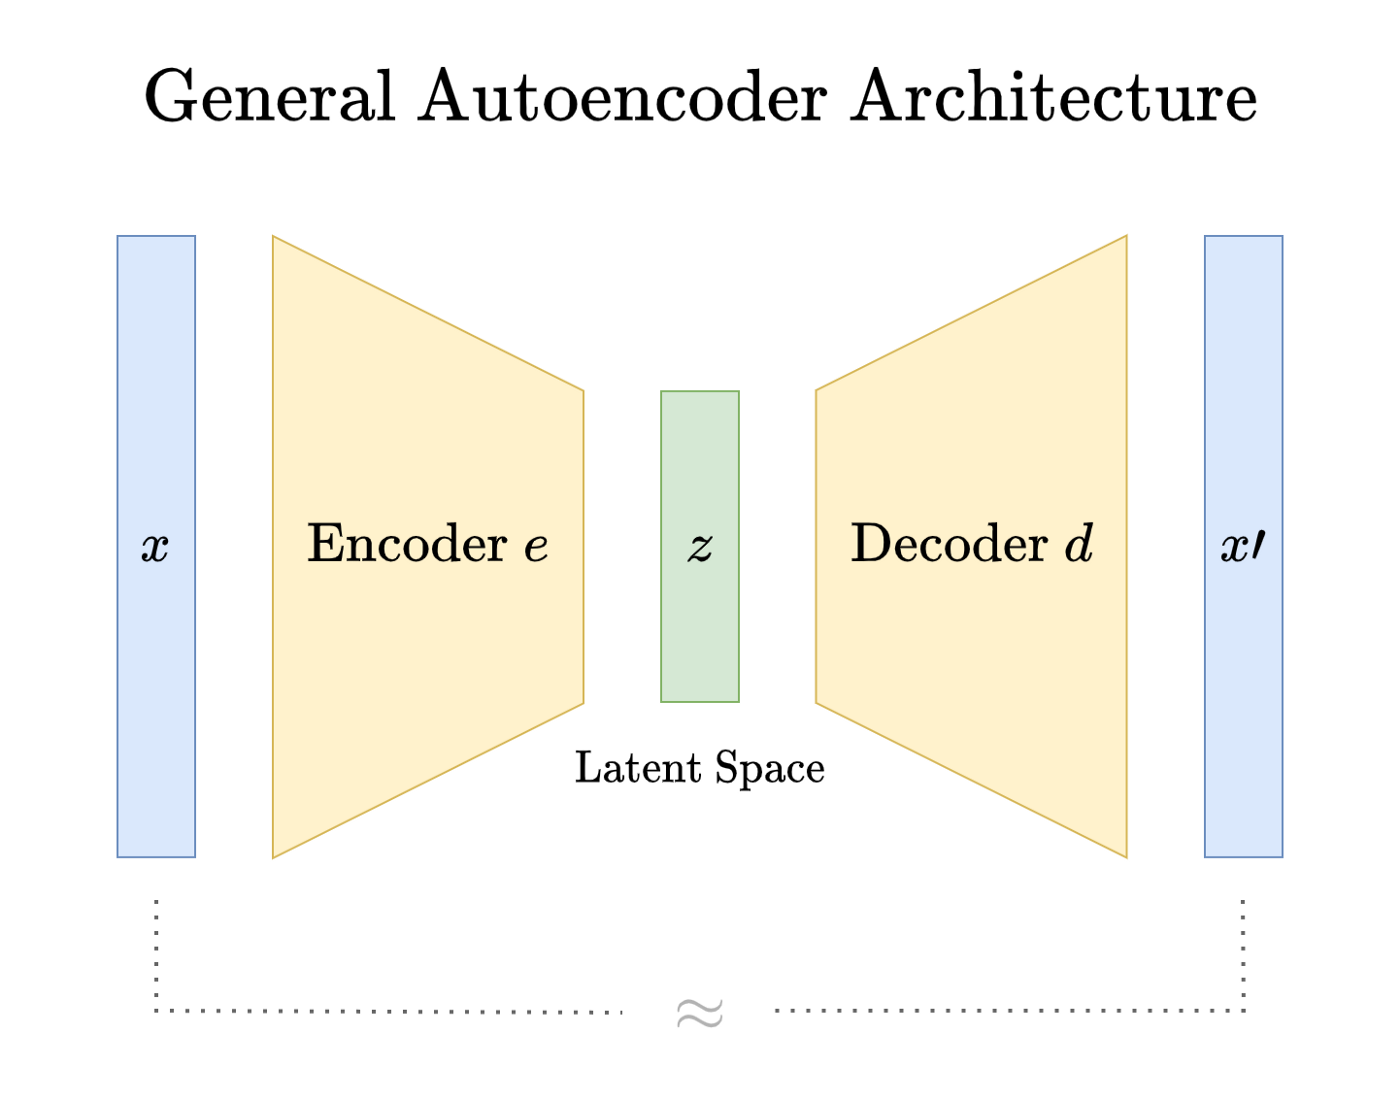

In [13]:
dim_code = 128

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [14]:
class Autoencoder(nn.Module):
    def __init__(self, dim_code=128):
        super(Autoencoder, self).__init__()
        self.dim_code = dim_code

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # 45×45 → 45×45
            nn.ReLU(True),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),  # 45×45 → 22×22 (нечётное → чётное)

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 22×22 → 22×22
            nn.ReLU(True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),  # 22×22 → 11×11

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 11×11 → 11×11
            nn.ReLU(True),
            nn.BatchNorm2d(128),
            nn.AdaptiveAvgPool2d((8, 8))  # Фиксируем размер 8×8
        )

        # Латентное представление
        self.fc_encoder = nn.Linear(128 * 8 * 8, dim_code)
        self.fc_decoder = nn.Linear(dim_code, 128 * 8 * 8)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8×8 → 16×16
            nn.ReLU(True),
            nn.BatchNorm2d(64),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 16×16 → 32×32
            nn.ReLU(True),
            nn.BatchNorm2d(32),

            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=1, padding=1),  # 32×32 → 32×32
            nn.Sigmoid()
        )

        # Дополнительный слой для точного восстановления размера 45×45
        self.final_upsample = nn.Upsample(size=(45, 45), mode='bilinear', align_corners=False)

    def forward(self, x):
        # Encoder
        encoded = self.encoder(x)  # [batch, 128, 8, 8]
        encoded_flat = encoded.view(encoded.size(0), -1)  # Раскладываем
        latent_code = self.fc_encoder(encoded_flat)  # Латентный код

        # Decoder
        decoded_flat = self.fc_decoder(latent_code)  # Восстанавливаем размерность
        decoded = decoded_flat.view(-1, 128, 8, 8)  # Возвращаем форму
        reconstruction = self.decoder(decoded)  # Частичная реконструкция
        reconstruction = self.final_upsample(reconstruction)  # Доводим до 45×45

        return reconstruction, latent_code

In [15]:
# Функция потерь — MSE (среднеквадратичная ошибка)
criterion = nn.MSELoss()

# Создаём экземпляр автоэнкодера
autoencoder = Autoencoder(dim_code=dim_code)

# Оптимизатор — Adam с разумными параметрами
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001, weight_decay=1e-5)

# Используем GPU, если доступно
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder.to(device)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): AdaptiveAvgPool2d(output_size=(8, 8))
  )
  (fc_encoder): Linear(in_features=8192, out_features=128, bias=True)
  (fc_decoder): Linear(in_features=128, out_features=8192, bias=True)
  (decoder): Sequential(

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [16]:
def train_autoencoder(model, train_loader, criterion, optimizer, num_epochs=50):
    model.train()
    train_losses = []

    for epoch in range(num_epochs):
        running_loss = 0.0

        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)

            optimizer.zero_grad()
            reconstruction, latent_code = model(data)
            loss = criterion(reconstruction, data)  # Теперь размеры совпадают!

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.6f}")

    return train_losses

# Настройка обучения
criterion = nn.MSELoss()
autoencoder = Autoencoder(dim_code=128).to(device)
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001, weight_decay=1e-5)

# Обучение
print("Начинаем обучение автоэнкодера...")
train_losses = train_autoencoder(autoencoder, train_loader, criterion, optimizer, num_epochs=50)

Начинаем обучение автоэнкодера...
Epoch [10/50], Loss: 0.003003
Epoch [20/50], Loss: 0.002683
Epoch [30/50], Loss: 0.002616
Epoch [40/50], Loss: 0.002592
Epoch [50/50], Loss: 0.002505


Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

Визуализация реконструкций:


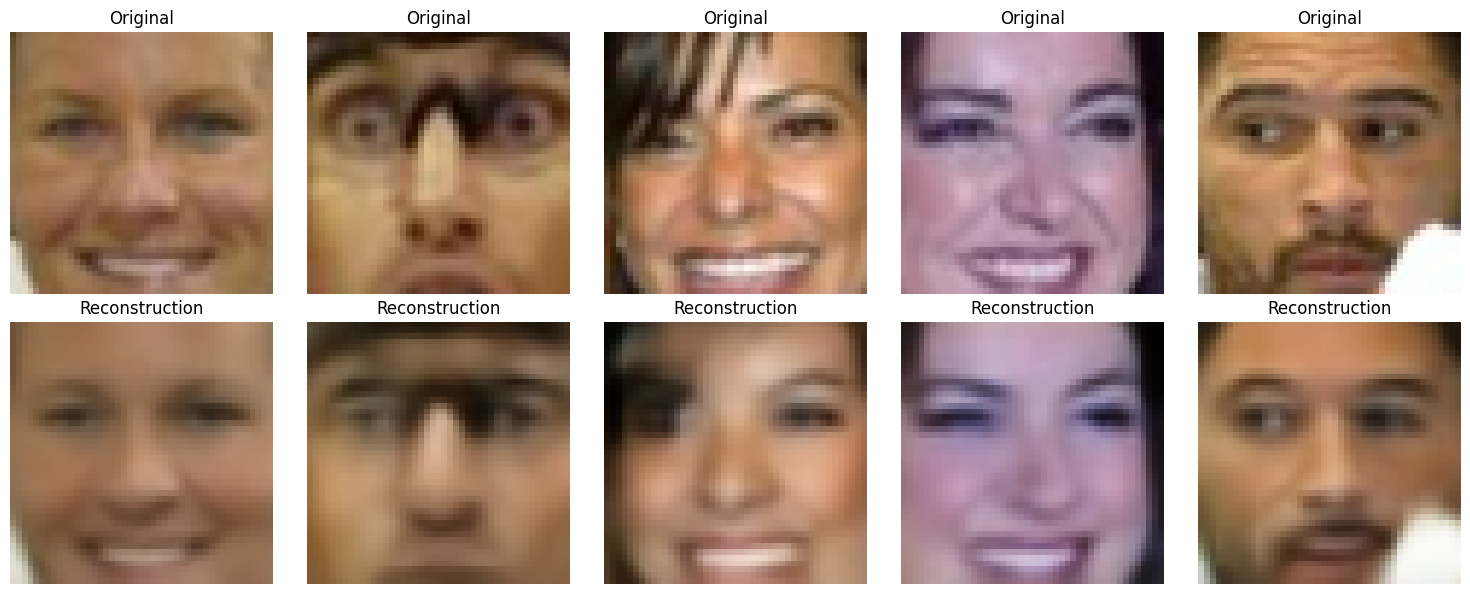

In [17]:
def visualize_reconstructions(model, data_loader, num_images=5):
    model.eval()
    with torch.no_grad():
        data, _ = next(iter(data_loader))
        data = data[:num_images].to(device)
        reconstructions, _ = model(data)

        data_cpu = data.cpu()
        reconstructions_cpu = reconstructions.cpu()

        fig, axes = plt.subplots(2, num_images, figsize=(15, 6))

        for i in range(num_images):
            img_orig = data_cpu[i].permute(1, 2, 0).numpy()
            axes[0, i].imshow(img_orig)
            axes[0, i].set_title('Original')
            axes[0, i].axis('off')

            img_recon = reconstructions_cpu[i].permute(1, 2, 0).numpy()
            axes[1, i].imshow(img_recon)
            axes[1, i].set_title('Reconstruction')
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.show()

print("Визуализация реконструкций:")
visualize_reconstructions(autoencoder, val_loader)

Что вы можете сказать про результат?

Автоэнкодер уловил общую структуру, однако над реконструкцией надо еще поработать


## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [18]:
# Получаем латентные векторы реальных изображений
autoencoder.eval()  # Переключаем модель в режим вывода

# Берём первую партию из датасета
data, _ = next(iter(train_loader))
data = data.to(device)

# Кодируем изображения
with torch.no_grad():
    _, latent_vectors = autoencoder(data)

# Переводим в numpy для анализа
latent_vectors_np = latent_vectors.cpu().numpy()

# Смотрим на статистику
print("Среднее значение:", latent_vectors_np.mean())
print("Стандартное отклонение:", latent_vectors_np.std())

Среднее значение: 0.0006903545
Стандартное отклонение: 0.18316594


In [19]:
# Параметры из анализа (замените на свои значения)
latent_dim = 128  # размер вашего кода
mean = latent_vectors_np.mean()  # среднее из шага 1
std = latent_vectors_np.std()    # стандартное отклонение из шага 1

# Генерируем 25 случайных векторов с правильным распределением
z_random = np.random.randn(25, latent_dim) * std + mean
z_random = torch.from_numpy(z_random).float().to(device)  # конвертируем в тензор

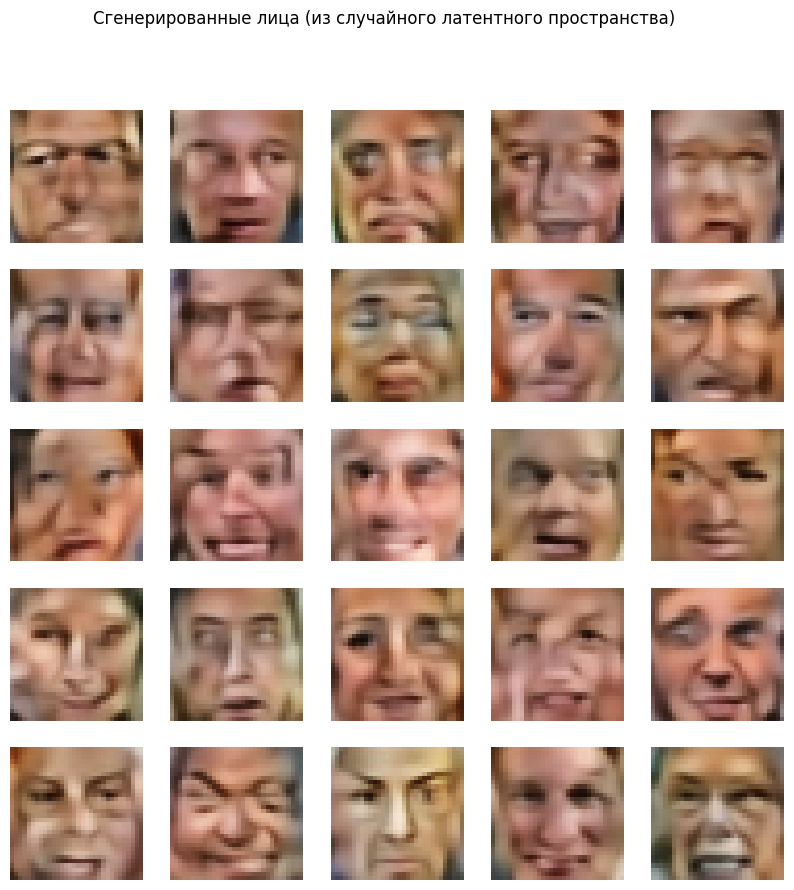

In [20]:
with torch.no_grad():
    # Шаг 1: Преобразуем вектор в карту признаков (размерность 4D)
    z_features = autoencoder.fc_decoder(z_random)  # [25, 128] -> [25, 128*H*W]
    z_features = z_features.view(z_random.size(0), 128, 8, 8)  # Раскладываем в карту (H, W зависят от вашей модели)

    # Шаг 2: Прогоняем через декодер
    generated_images = autoencoder.decoder(z_features)  # [25, 3, 45, 45]

    # Нормализация для отображения
    generated_images = torch.clamp(generated_images, 0, 1)

# Визуализация
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.ravel()

for i in range(25):
    img = generated_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].axis('off')

plt.suptitle("Сгенерированные лица (из случайного латентного пространства)")
plt.show()

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [21]:
attrs_df = pd.DataFrame(attrs)
# Отбираем 15 изображений с чёткой улыбкой (Smiling > 1)
smiling_sample = attrs_df[attrs_df['Smiling'] > 1].sample(15, random_state=42)

# Отбираем 15 изображений без улыбки (Smiling < -1)
non_smiling_sample = attrs_df[attrs_df['Smiling'] < -1].sample(15, random_state=42)

print(f"Отобрано улыбающихся (Smiling > 1): {len(smiling_sample)}")
print(f"Отобрано без улыбки (Smiling < -1): {len(non_smiling_sample)}")

# Проверяем распределение значений
print(f"Значения Smiling в улыбающейся группе: {smiling_sample['Smiling'].values}")
print(f"Значения Smiling в группе без улыбки: {non_smiling_sample['Smiling'].values}")

Отобрано улыбающихся (Smiling > 1): 15
Отобрано без улыбки (Smiling < -1): 15
Значения Smiling в улыбающейся группе: [1.09929066294 2.2204106225 1.07020481385 1.92016716226 1.79378324045
 1.26638954367 1.60749956341 1.00563328758 1.15069733809 1.95186002044
 2.02606154464 1.10073401321 1.34079474428 2.66415596971 2.32874373144]
Значения Smiling в группе без улыбки: [-1.25837044768 -2.25576380144 -1.83732102679 -1.48466278221
 -1.58998938689 -1.21716674169 -1.02539916183 -1.14450993114
 -1.16974000126 -1.52381002389 -1.17657313484 -1.1049908647 -1.32782467351
 -1.09046386397 -1.37911102306]


In [22]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import torch

class SmileDataset(Dataset):
    def __init__(self, image_indices, images_array, transform=None):
        self.image_indices = image_indices  # Индексы изображений в массиве images
        self.images_array = images_array  # Массив всех изображений из fetch_dataset
        self.transform = transform

    def __len__(self):
        return len(self.image_indices)

    def __getitem__(self, idx):
        img_idx = self.image_indices[idx]
        # Берём изображение из массива images по индексу
        img = self.images_array[img_idx]
        # Преобразуем numpy array в PIL Image
        image = Image.fromarray(img)
        if self.transform:
            image = self.transform(image)
        return image, img_idx

# Преобразования для изображений
transform = transforms.Compose([
    transforms.ToTensor(),  # Нормализация в [0,1]
])

# Получаем индексы изображений для обеих групп
smiling_indices = smiling_sample.index.tolist()
non_smiling_indices = non_smiling_sample.index.tolist()

# Создаём датасеты
smiling_dataset = SmileDataset(smiling_indices, images, transform=transform)
non_smiling_dataset = SmileDataset(non_smiling_indices, images, transform=transform)

# DataLoaders
smiling_loader = DataLoader(smiling_dataset, batch_size=15, shuffle=False)
non_smiling_loader = DataLoader(non_smiling_dataset, batch_size=15, shuffle=False)

In [23]:
def get_latent_vectors(model, dataloader, device):
    """Пропускает изображения через encoder и возвращает латентные векторы"""
    model.eval()
    latent_vectors = []
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            _, latents = model(images)  # Получаем латентные коды
            latent_vectors.append(latents.cpu())
    return torch.cat(latent_vectors, dim=0)

# Получаем латентные векторы для обеих групп
smiling_latents = get_latent_vectors(autoencoder, smiling_loader, device)
non_smiling_latents = get_latent_vectors(autoencoder, non_smiling_loader, device)

print(f"Размер латентных векторов улыбающихся: {smiling_latents.shape}")
print(f"Размер латентных векторов без улыбки: {non_smiling_latents.shape}")

Размер латентных векторов улыбающихся: torch.Size([15, 128])
Размер латентных векторов без улыбки: torch.Size([15, 128])


In [24]:
# Вычисляем средние векторы
mean_smiling = smiling_latents.mean(dim=0)  # Форма: [128]
mean_non_smiling = non_smiling_latents.mean(dim=0)  # Форма: [128]

# Вектор улыбки — разность средних
smile_vector = mean_smiling - mean_non_smiling


print(f"Вектор улыбки вычислен. Форма: {smile_vector.shape}")
print(f"Норма вектора улыбки: {torch.norm(smile_vector):.4f}")

Вектор улыбки вычислен. Форма: torch.Size([128])
Норма вектора улыбки: 1.0273


In [25]:
def add_smile_to_image(model, image_index, images_array, smile_vector, device, alpha=1.0):
    """Добавляет улыбку к изображению по его индексу в массиве images"""
    # Берём изображение по индексу и преобразуем в тензор
    img = images_array[image_index]
    transform = transforms.Compose([transforms.ToTensor()])
    original_pil = Image.fromarray(img)
    original_tensor = transform(original_pil).unsqueeze(0).to(device)  # Добавляем batch dim и перемещаем на device

    # Кодируем исходное изображение
    model.eval()
    with torch.no_grad():
        _, latent_code = model(original_tensor)
        # Перемещаем smile_vector на то же устройство, что и latent_code
        smile_vector_on_device = smile_vector.to(device)
        # Добавляем вектор улыбки
        latent_with_smile = latent_code + alpha * smile_vector_on_device.unsqueeze(0)
        # Декодируем
        decoded_flat = model.fc_decoder(latent_with_smile)
        decoded = decoded_flat.view(-1, 128, 8, 8)
        reconstruction = model.decoder(decoded)
        reconstructed_with_smile = model.final_upsample(reconstruction)

    return original_tensor.squeeze(0), reconstructed_with_smile.squeeze(0)

# Выбираем тестовое изображение без улыбки (не из обучающей выборки)
test_image_idx = non_smiling_sample.iloc[0].name  # Берём первый индекс из группы без улыбки

# Добавляем улыбку
original, with_smile = add_smile_to_image(
    autoencoder, test_image_idx, images, smile_vector, device, alpha=1.0
)

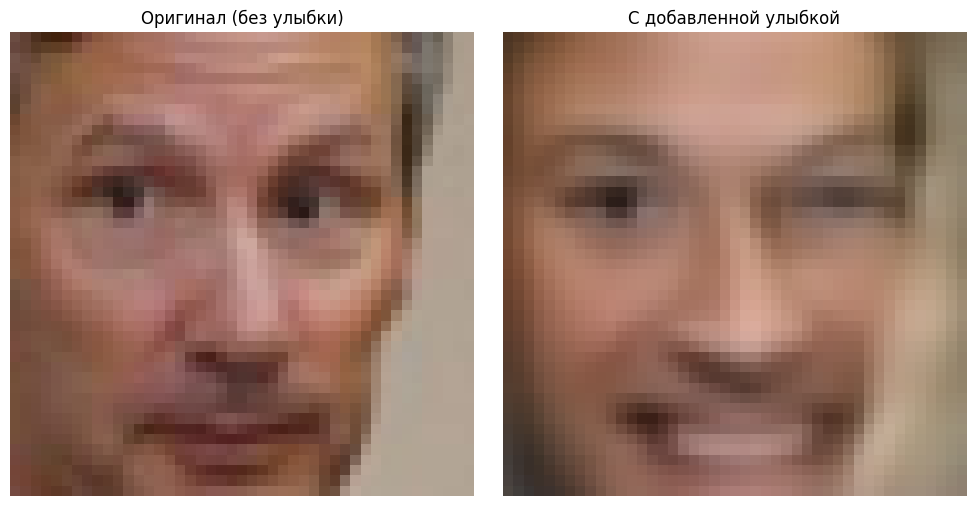

In [26]:
def visualize_smile_transformation(original, with_smile):
    """Визуализирует исходное и изменённое изображение"""
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Исходное изображение
    orig_img = original.permute(1, 2, 0).cpu().numpy()
    axes[0].imshow(orig_img)
    axes[0].set_title("Оригинал (без улыбки)")
    axes[0].axis('off')

    # Изображение с добавленной улыбкой
    smile_img = with_smile.permute(1, 2, 0).cpu().numpy()
    axes[1].imshow(smile_img)
    axes[1].set_title("С добавленной улыбкой")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Показываем результат
visualize_smile_transformation(original, with_smile)

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [27]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [47]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.BatchNorm2d(64),
            nn.ReLU(True)
        )

        self.fc_mu = nn.Linear(3136, latent_dim)
        self.fc_logsigma = nn.Linear(3136, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.Sigmoid()  # Заменяем BatchNorm + ReLU на Sigmoid для корректного диапазона [0,1]
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # Добавляем eps=1e-8 для численной стабильности
            std = torch.exp(0.5 * logsigma) + 1e-8
            eps = torch.randn_like(std)
            z = mu + eps * std
            return z
        else:
            return mu

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(h.size(0), 64, 7, 7)
        reconstruction = self.decoder(h)
        return reconstruction

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [48]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений
    """
    # Используем torch.exp(2 * logsigma) для sigma^2, добавляем eps для стабильности
    sigma2 = torch.exp(2 * logsigma)
    loss = -0.5 * torch.sum(1 + logsigma - mu ** 2 - sigma2, dim=1)
    return torch.mean(loss)



def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции
    """
    criterion = nn.BCEWithLogitsLoss(reduction='mean')  # Исправлено 'reduction' → 'reduction'
    loss = criterion(reconstruction, x)
    return loss


def loss_vae(x, mu, logsigma, reconstruction):
    kl_loss = KL_divergence(mu, logsigma)
    ll_loss = log_likelihood(x, reconstruction)
    total_loss = kl_loss + ll_loss  # Убрано минус перед kl_loss: KL-дивергенция уже положительна
    return total_loss

И обучим модель:

In [52]:
criterion = loss_vae

autoencoder = VAE().to(device)

optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [53]:
num_epochs = 10

for epoch in range(num_epochs):
    autoencoder.train()
    running_loss = 0.0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        mu, logsigma, reconstruction = autoencoder(data)
        loss = loss_vae(data, mu, logsigma, reconstruction)

        # Проверяем на nan перед backward
        if torch.isnan(loss):
            print(f"NaN обнаружен на батчи {batch_idx}, эпоха {epoch+1}")
            break

        loss.backward()
        # Ограничиваем градиенты для предотвращения взрывов
        torch.nn.utils.clip_grad_norm_(autoencoder.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

print('Обучение завершено!')

Epoch [1/10], Loss: -8.8172
Epoch [2/10], Loss: -9.1224
Epoch [3/10], Loss: -9.1242
Epoch [4/10], Loss: -9.1252
Epoch [5/10], Loss: -9.1253
Epoch [6/10], Loss: -9.1255
Epoch [7/10], Loss: -9.1258
Epoch [8/10], Loss: -9.1258
Epoch [9/10], Loss: -9.1259
Epoch [10/10], Loss: -9.1259
Обучение завершено!


Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

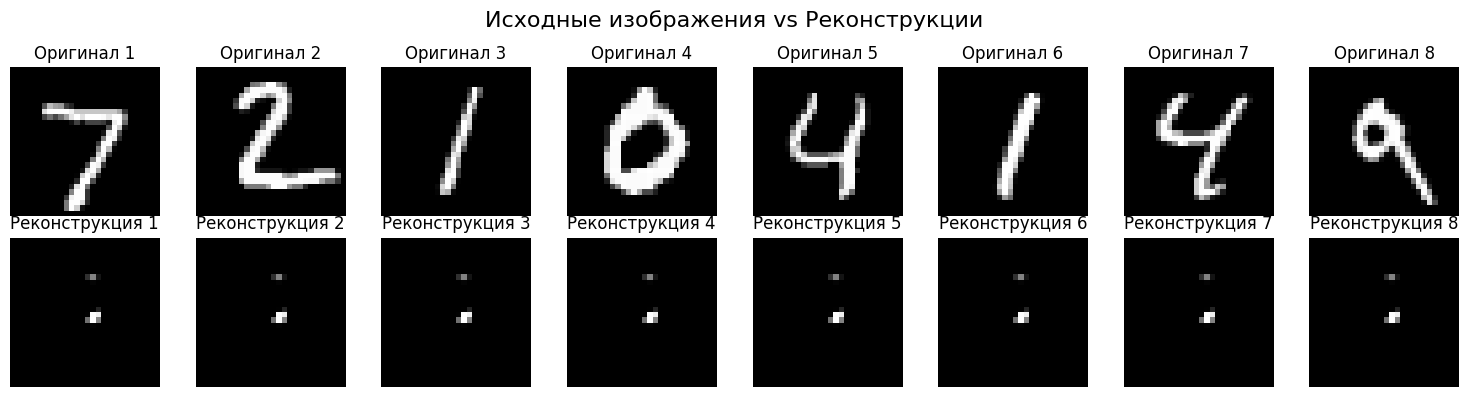

In [54]:
def visualize_reconstructions(model, test_loader, num_images=8, device='cuda'):
    """
    Визуализирует исходные изображения и их реконструкции из тестового датасета.

    Args:
        model: обученная модель VAE
        test_loader: DataLoader для тестового набора
        num_images: количество изображений для отображения
        device: устройство (cuda или cpu)
    """
    # Переключаем модель в режим оценки
    model.eval()

    # Берём один батч из тестового загрузчика
    data, _ = next(iter(test_loader))
    data = data[:num_images].to(device)  # Берём первые num_images изображений


    # Пропускаем через модель (без вычисления градиентов)
    with torch.no_grad():
        mu, logsigma, reconstruction = model(data)


    # Переносим данные на CPU для визуализации
    data_cpu = data.cpu()
    reconstruction_cpu = reconstruction.cpu()

    # Создаём фигуру с подзаголовками
    fig, axes = plt.subplots(2, num_images, figsize=(15, 4))
    fig.suptitle('Исходные изображения vs Реконструкции', fontsize=16)


    for i in range(num_images):
        # Отображаем исходное изображение
        axes[0, i].imshow(data_cpu[i].squeeze(), cmap='gray')
        axes[0, i].set_title(f'Оригинал {i+1}')
        axes[0, i].axis('off')

        # Отображаем реконструкцию
        axes[1, i].imshow(reconstruction_cpu[i].squeeze(), cmap='gray')
        axes[1, i].set_title(f'Реконструкция {i+1}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Вызываем функцию визуализации
visualize_reconstructions(autoencoder, test_loader, num_images=8, device=device)

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

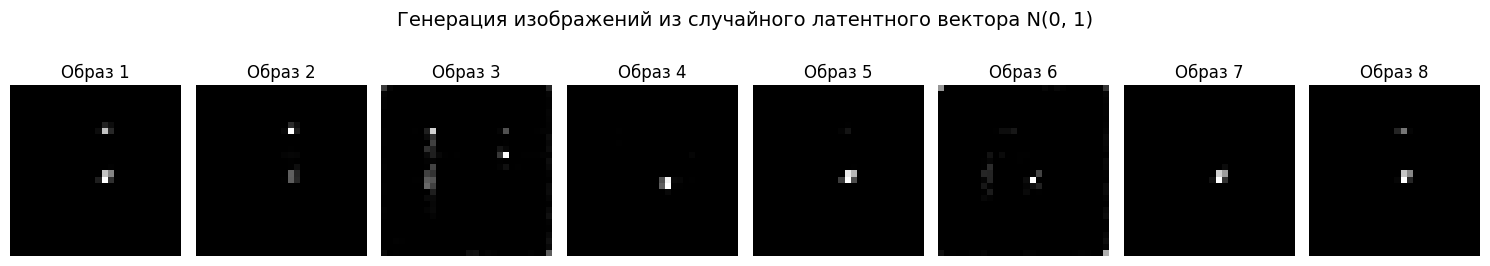

In [55]:
def generate_from_random_latent(model, num_samples=8, latent_dim=128, device='cuda'):
    """
    Генерирует изображения из случайных векторов, взятых из нормального распределения N(0, 1).

    Args:
        model: обученная модель VAE
        num_samples: количество изображений для генерации
        latent_dim: размерность латентного пространства
        device: устройство (cuda или cpu)
    """
    # Переключаем модель в режим оценки
    model.eval()

    # Создаём случайные векторы из N(0, 1)
    z = torch.randn(num_samples, latent_dim).to(device)

    # Пропускаем через декодер
    with torch.no_grad():
        generated = model.decode(z)

    # Переносим на CPU для визуализации
    generated_cpu = generated.cpu()

    # Визуализируем
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    fig.suptitle('Генерация изображений из случайного латентного вектора N(0, 1)', fontsize=14)

    for i in range(num_samples):
        axes[i].imshow(generated_cpu[i].squeeze(), cmap='gray')
        axes[i].set_title(f'Образ {i+1}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Вызываем функцию генерации
generate_from_random_latent(autoencoder, num_samples=8, latent_dim=128, device=device)

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

Собрано 1000 латентных векторов размерности 128
Применяем t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE завершено!


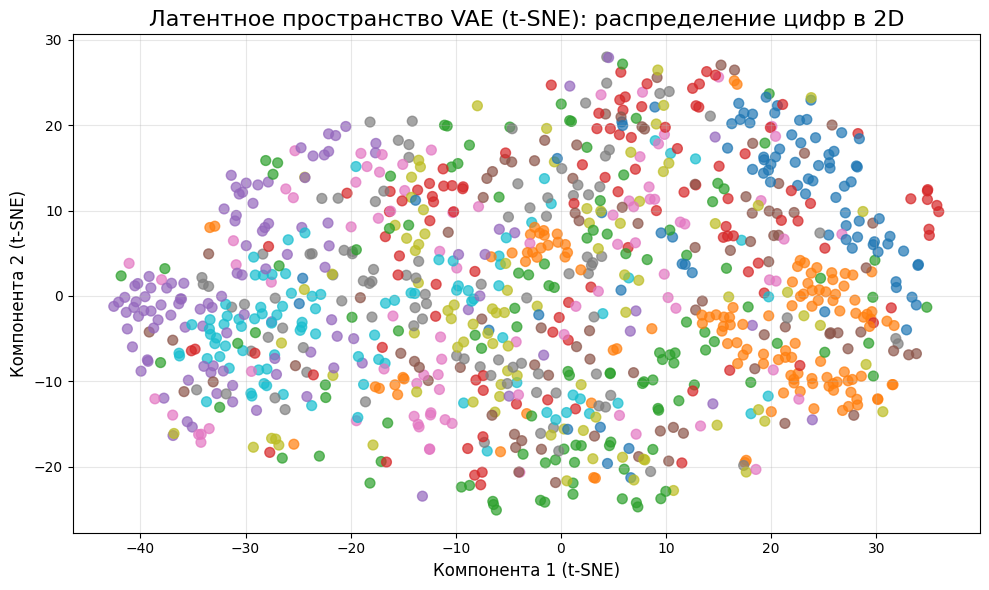

In [84]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_latent_space(model, test_loader, device='cuda', n_samples=1000):
    """
    Визуализирует латентное пространство VAE с помощью t-SNE, раскрашивая точки по классам цифр.

    Args:
        model: обученная модель VAE
        test_loader: DataLoader для тестового набора
        device: устройство (cuda или cpu)
        n_samples: количество образцов для визуализации (для ускорения)
    """
    # Переключаем модель в режим оценки
    model.eval()

    # Собираем латентные представления и метки
    latent_vectors = []
    labels = []

    with torch.no_grad():
        for data, target in test_loader:
            # Переносим данные на устройство
            data = data.to(device)

            # Получаем латентные векторы (mu)
            mu, _ = model.encode(data)

            # Сохраняем латентные векторы и метки
            latent_vectors.append(mu.cpu().numpy())
            labels.append(target.numpy())

            # Если собрали достаточно образцов, прерываем
            if len(np.concatenate(latent_vectors)) >= n_samples:
                break

    # Объединяем все собранные данные
    latent_vectors = np.concatenate(latent_vectors)[:n_samples]
    labels = np.concatenate(labels)[:n_samples]

    print(f"Собрано {latent_vectors.shape[0]} латентных векторов размерности {latent_vectors.shape[1]}")


    # Применяем t-SNE для уменьшения размерности до 2D
    print("Применяем t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    latent_2d = tsne.fit_transform(latent_vectors)

    print("t-SNE завершено!")

    # Визуализация
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        latent_2d[:, 0],
        latent_2d[:, 1],
        c=labels,
        cmap='tab10',  # 10 цветов для 10 цифр
        alpha=0.7,
        s=50
    )

    # Добавляем легенду
    legend1 = plt.legend(
        *scatter.legend_elements(),
        title="Цифры",
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )
    plt.gca().add_artist(legend1)

    plt.title('Латентное пространство VAE (t-SNE): распределение цифр в 2D', fontsize=16)
    plt.xlabel('Компонента 1 (t-SNE)', fontsize=12)
    plt.ylabel('Компонента 2 (t-SNE)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Вызываем функцию визуализации
visualize_latent_space(autoencoder, test_loader, device=device)

Слишком сильно перемешены многие группы, однако у нескольких можно выделить центр кластеров, например оранжевые, фиолетовые и синие

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [66]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim

        # Энкодер (вход: (1+10) -> выход: mu, logsigma)
        self.encoder = nn.Sequential(
            nn.Conv2d(11, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

        # Декодер (вход: (latent_dim + 10) -> выход: (1, 28, 28))
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + 10, 512),
            nn.ReLU(),
            nn.Linear(512, 64 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(dim=1, unflattened_size=(64, 7, 7)),
            nn.Upsample(scale_factor=2),
            nn.ConvTranspose2d(64, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.ConvTranspose2d(32, 1, 3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x, class_num):
        # class_num: (batch_size, 10)
        # x: (batch_size, 1, 28, 28)

        # Распространяем класс на все пиксели (делаем (batch_size, 10, 28, 28))
        class_expanded = class_num.unsqueeze(2).unsqueeze(3)  # (B, 10, 1, 1)
        class_expanded = class_expanded.expand(-1, -1, x.size(2), x.size(3))  # (B, 10, 28, 28)

        # Теперь объединяем: (B, 1, 28, 28) + (B, 10, 28, 28) -> (B, 11, 28, 28)
        x_with_class = torch.cat([x, class_expanded], dim=1)

        hidden = self.encoder(x_with_class)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        return mu, logvar, class_num

    def gaussian_sampler(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + std * eps
        else:
            return mu

    def decode(self, z, class_num):
        z_with_class = torch.cat([z, class_num], dim=1)
        return self.decoder(z_with_class)

    def forward(self, x, class_num):
        mu, logvar, _ = self.encode(x, class_num)
        z = self.gaussian_sampler(mu, logvar)
        return self.decode(z, class_num), mu, logvar

In [64]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [69]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
cvae_model = CVAE(latent_dim=20).to(device)
optimizer = optim.Adam(cvae_model.parameters(), lr=1e-3)

num_epochs = 10

for epoch in range(num_epochs):
    cvae_model.train()
    total_loss = 0

    # Проход по батчам
    for data, target in train_loader:
        data = data.to(device)
        target_onehot = torch.nn.functional.one_hot(target, num_classes=10).float().to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = cvae_model(data, target_onehot)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Вывод прогресса после завершения каждой эпохи
    avg_loss = total_loss / len(train_loader)
    print(f'Эпоха [{epoch + 1}/{num_epochs}], Средняя ошибка (Loss): {avg_loss:.4f}')

Эпоха [1/10], Средняя ошибка (Loss): 4100.4142
Эпоха [2/10], Средняя ошибка (Loss): 3385.2554
Эпоха [3/10], Средняя ошибка (Loss): 3259.6204
Эпоха [4/10], Средняя ошибка (Loss): 3196.3014
Эпоха [5/10], Средняя ошибка (Loss): 3157.2954
Эпоха [6/10], Средняя ошибка (Loss): 3125.3336
Эпоха [7/10], Средняя ошибка (Loss): 3101.8649
Эпоха [8/10], Средняя ошибка (Loss): 3081.9735
Эпоха [9/10], Средняя ошибка (Loss): 3067.4973
Эпоха [10/10], Средняя ошибка (Loss): 3054.1269


### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

In [70]:
# Для цифры 5
y_5 = torch.tensor([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]])

# Для цифры 7
y_7 = torch.tensor([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]])

In [71]:
latent_dim = 20  # или ваша размерность
z = torch.randn(1, latent_dim)  # (1, 20) — батч из одной картинки<тут нужно научиться сэмплировать из декодера цифры определенного класса>

In [72]:
def sample_digit(cvae_model, z, digit_class, device='cuda'):
    """
    Генерирует изображение цифры заданного класса из латентного вектора z.

    Args:
        cvae_model: обученная модель CVAE
        z: латентный вектор (torch.Tensor, размерность (1, latent_dim))
        digit_class: номер класса (0-9)
        device: устройство

    Returns:
        Сгенерированное изображение (torch.Tensor)
    """
    # Переводим модель в режим инференса (чтобы не семплировали шум, а брали mu)
    cvae_model.eval()

    # Создаем one-hot вектор для класса
    one_hot = torch.zeros(1, 10)  # 10 классов
    one_hot[0, digit_class] = 1.0
    one_hot = one_hot.to(device)
    z = z.to(device)

    # Декодируем
    with torch.no_grad():
        generated_image = cvae_model.decode(z, one_hot)

    return generated_image

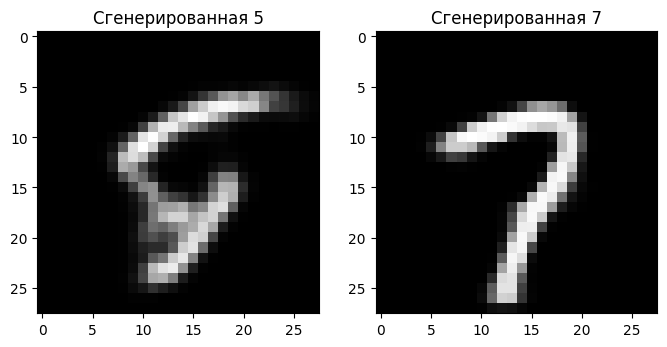

In [73]:
# Создаем случайный вектор
z = torch.randn(1, 20)

# Генерируем две картинки
img_5 = sample_digit(cvae_model, z, digit_class=5)
img_7 = sample_digit(cvae_model, z, digit_class=7)

# Визуализируем
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(img_5.cpu().squeeze(), cmap='gray')
ax1.set_title("Сгенерированная 5")
ax2.imshow(img_7.cpu().squeeze(), cmap='gray')
ax2.set_title("Сгенерированная 7")
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [79]:
def get_latent_representations(model, data_loader, device='cuda', model_type='cvae'):
    """
    Извлекает латентные представления (mu) из модели.

    Args:
        model: обученная модель (VAE или CVAE)
        data_loader: DataLoader для данных
        device: устройство
        model_type: 'cvae' или 'vae'
    Returns:
        latent_vectors, labels
    """
    model.eval()
    latent_vectors = []
    labels = []

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            target = target.to(device)

            if model_type == 'cvae':
                # Для CVAE нужен one-hot вектор класса
                target_onehot = torch.nn.functional.one_hot(target, num_classes=10).float().to(device)
                # Получаем все три возвращаемых значения
                mu, logvar, _ = model.encode(data, target_onehot)
            else:  # VAE
                mu, logvar = model.encode(data)

            latent_vectors.append(mu.cpu().numpy())
            labels.extend(target.cpu().numpy())

    latent_vectors = np.concatenate(latent_vectors, axis=0)
    return latent_vectors, np.array(labels)

In [80]:
def visualize_latent_space(latent_vectors, labels, title="Латентное пространство"):
    """
    Визуализирует латентное пространство с помощью t-SNE.
    """
    # Применяем t-SNE для уменьшения размерности до 2D
    print("Применяем t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    latent_2d = tsne.fit_transform(latent_vectors)

    # Визуализация
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap='tab10', alpha=0.7, s=5)
    plt.colorbar(scatter, ticks=range(10))
    plt.title(title, fontsize=16)
    plt.xlabel("Компонента 1 t-SNE", fontsize=12)
    plt.ylabel("Компонента 2 t-SNE", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    return latent_2d

In [81]:
# test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
# test_loader_small = DataLoader(test_dataset, batch_size=500, shuffle=True)  # берём 500 образцов

Применяем t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


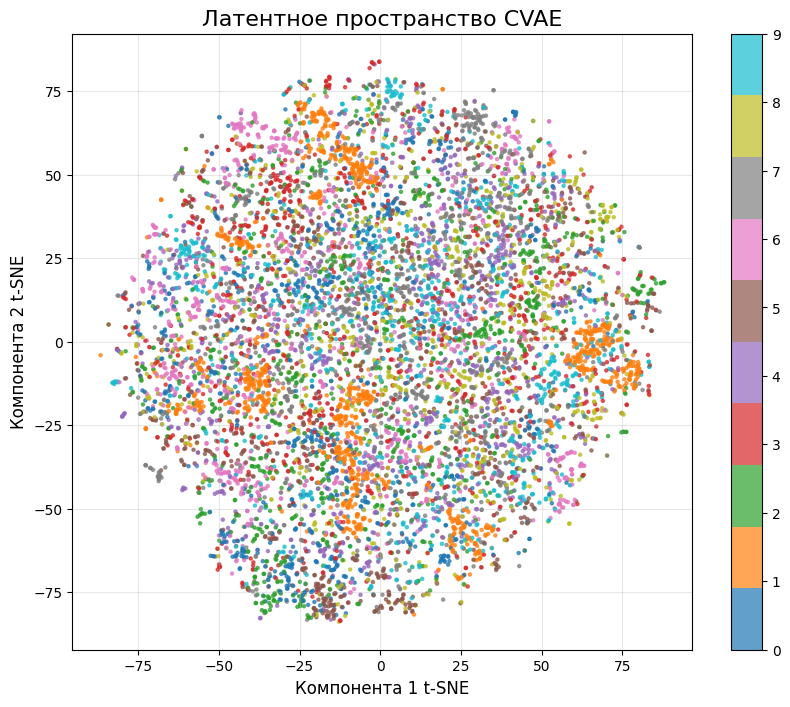

array([[ 40.750553 ,  56.002632 ],
       [-25.904388 ,  -9.414147 ],
       [ -3.2334309, -16.124905 ],
       ...,
       [ 10.550791 , -41.20489  ],
       [  3.3803856, -79.95643  ],
       [-51.07298  , -36.384777 ]], dtype=float32)

In [83]:
# Получаем латентные векторы для CVAE
latent_cvae, labels_cvae = get_latent_representations(cvae_model, test_loader, device=device, model_type='cvae')

# Визуализируем
visualize_latent_space(latent_cvae, labels_cvae, "Латентное пространство CVAE")

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [86]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms

In [87]:
# Загрузка MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
X_train = train_dataset.data.float() / 255.0  # Нормализация [0,1]
y_train = train_dataset.targets

# Берём часть данных для скорости
X_train = X_train[:10000]
y_train = y_train[:10000]

# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [88]:
def add_noise(X, noise_factor=0.5):
    """Добавляет гауссовский шум к изображениям"""
    noise = noise_factor * torch.randn_like(X)
    X_noisy = X + noise
    # Ограничиваем значения в диапазоне [0, 1]
    X_noisy = torch.clamp(X_noisy, 0.0, 1.0)
    return X_noisy

# Создаём зашумлённые версии
X_train_noisy = add_noise(X_train)
X_test_noisy = add_noise(X_test)

In [89]:

batch_size = 128

# Train DataLoader (зашумлённые входные данные, чистые целевые)
train_dataset_noisy = TensorDataset(X_train_noisy.unsqueeze(1), X_train.unsqueeze(1))
train_loader = DataLoader(train_dataset_noisy, batch_size=batch_size, shuffle=True)

# Test DataLoader
test_dataset_noisy = TensorDataset(X_test_noisy.unsqueeze(1), X_test.unsqueeze(1))
test_loader = DataLoader(test_dataset_noisy, batch_size=batch_size, shuffle=False)

In [90]:
class DenoisingAE(nn.Module):
    def __init__(self, input_size=28, latent_dim=64):
        super(DenoisingAE, self).__init__()
        self.latent_dim = latent_dim
        self.input_size = input_size

        # Энкодер
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * (input_size // 4) * (input_size // 4), latent_dim),
            nn.ReLU()
        )

        # Декодер
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * (input_size // 4) * (input_size // 4)),
            nn.ReLU(),
            nn.Unflatten(dim=1, unflattened_size=(64, input_size // 4, input_size // 4)),
            nn.Upsample(scale_factor=2),
            nn.ConvTranspose2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.ConvTranspose2d(32, 1, 3, padding=1),
            nn.Sigmoid()  # Для значений [0,1]
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

In [91]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = DenoisingAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for noisy_batch, clean_batch in train_loader:
        noisy_batch = noisy_batch.to(device)
        clean_batch = clean_batch.to(device)

        optimizer.zero_grad()
        output = model(noisy_batch)
        loss = criterion(output, clean_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f'Эпоха {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader):.4f}')

Эпоха 1/20, Train Loss: 0.1219
Эпоха 2/20, Train Loss: 0.1125
Эпоха 3/20, Train Loss: 0.1125
Эпоха 4/20, Train Loss: 0.1126
Эпоха 5/20, Train Loss: 0.1125
Эпоха 6/20, Train Loss: 0.1125
Эпоха 7/20, Train Loss: 0.1126
Эпоха 8/20, Train Loss: 0.1125
Эпоха 9/20, Train Loss: 0.1126
Эпоха 10/20, Train Loss: 0.1125
Эпоха 11/20, Train Loss: 0.1126
Эпоха 12/20, Train Loss: 0.1126
Эпоха 13/20, Train Loss: 0.1125
Эпоха 14/20, Train Loss: 0.1125
Эпоха 15/20, Train Loss: 0.1125
Эпоха 16/20, Train Loss: 0.1125
Эпоха 17/20, Train Loss: 0.1126
Эпоха 18/20, Train Loss: 0.1126
Эпоха 19/20, Train Loss: 0.1125
Эпоха 20/20, Train Loss: 0.1126


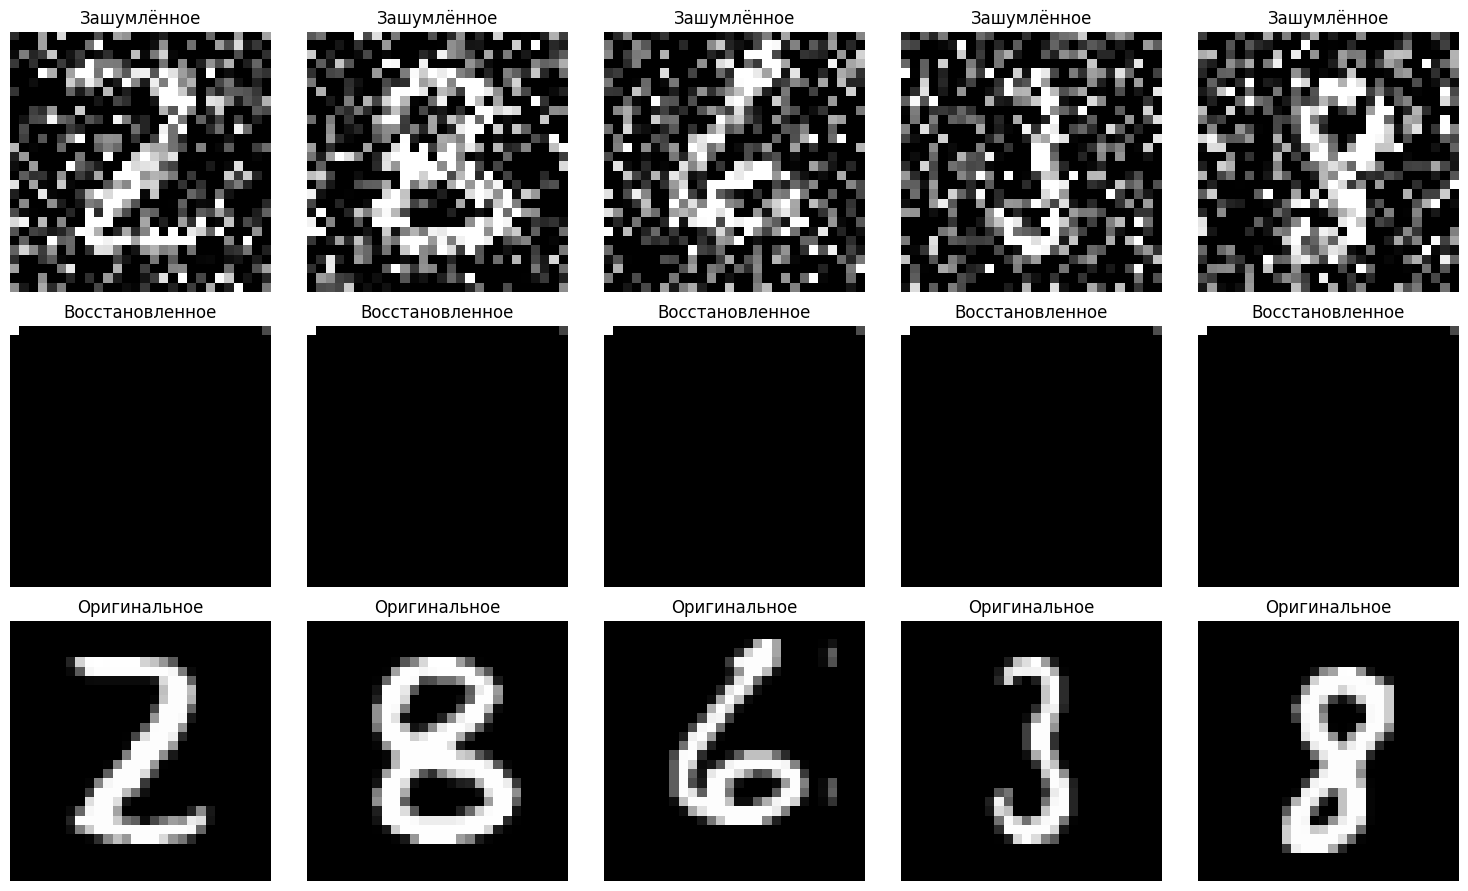

In [92]:
def visualize_denoising(model, test_loader, device, num_images=5):
    """Визуализирует процесс удаления шума"""
    model.eval()
    fig, axes = plt.subplots(3, num_images, figsize=(15, 9))

    with torch.no_grad():
        for i, (noisy_batch, clean_batch) in enumerate(test_loader):
            noisy_batch = noisy_batch.to(device)
            clean_batch = clean_batch.cpu()

            reconstructed = model(noisy_batch).cpu()
            noisy_batch = noisy_batch.cpu()

            # Берём первые num_images изображений из батча
            for j in range(num_images):
                axes[0, j].imshow(noisy_batch[j].squeeze(), cmap='gray')
                axes[0, j].set_title('Зашумлённое')
                axes[0, j].axis('off')

                axes[1, j].imshow(reconstructed[j].squeeze(), cmap='gray')
                axes[1, j].set_title('Восстановленное')
                axes[1, j].axis('off')


                axes[2, j].imshow(clean_batch[j].squeeze(), cmap='gray')
                axes[2, j].set_title('Оригинальное')
                axes[2, j].axis('off')
            break  # Только первый батч


    plt.tight_layout()
    plt.show()

# Запускаем визуализацию
visualize_denoising(model, test_loader, device)

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
codes = <поучите латентные представления картинок из трейна>

In [ ]:
# обучаем LSHForest
from sklearn.neighbors import LSHForest
lshf = LSHForest(n_estimators=50).fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей

  code = <получение латентного представления image>

  (distances,),(idx,) = lshf.kneighbors(code, n_neighbors=n_neighbors)

  return distances, X_train[idx]

In [ ]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
    plt.show()

In [ ]:
<тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>